# Feature experiment — per-paper term-overlap vs. the use case's own search brief

**ELI5:** every use case's `usecase.json` search brief lists the terms an analyst said
mattered — `terms_must_include`, `terms_nice_to_have`, `terms_exclude` — already
broadcast onto every paper row in `papers_combined.parquet`. This notebook asks a
narrow, cheap question: **does a paper's own title+abstract actually contain those
terms, and if so, does that overlap track the analyst's `positive`/`negative` call?**
If yes, it's a free, interpretable feature for a future classifier's feature matrix
alongside the embedding.

This is a **viability check**, not a feature-matrix build — no model is trained here.

**Prior art in this repo, and how this differs:** `eda/explore_usecase_definitions.ipynb`
§3 already checked *whole-corpus* coverage (what % of a use case's papers mention *any*
`must_include` term, substring match). This notebook goes further: a **per-paper**,
**per-term** fraction (not just "any hit"), **whole-word** matching instead of substring
(justified in §2), and — the actual point — whether that per-paper score **separates
`positive` from `negative` papers**, and how it relates to the existing `relevance_score`.
`reports/ner_model_notes.md` / `combined_features_notes.md` tested a *different* idea
(generic spaCy entity extraction) and found it weak — that result doesn't transfer here
by assumption; this is tested fresh, on its own merits.

In [1]:
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.metrics import roc_auc_score

DATA_PATH = "../../data/processed/papers_combined.parquet"

# Same visual convention as notebooks/eda/*.ipynb (validated categorical palette —
# see the dataviz guidance this repo follows: blue/red as two fixed categorical slots).
POSITIVE_COLOR = "#2a78d6"   # categorical slot 1 (blue)
NEGATIVE_COLOR = "#e34948"   # categorical slot 6 (red)

plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "text.color": "#0b0b0b",
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.6,
    "axes.axisbelow": True,
    "font.size": 10,
})

df = pd.read_parquet(DATA_PATH)
print(f"Loaded {df.shape[0]} rows, {df.shape[1]} columns from {DATA_PATH}")
print(f"use cases: {sorted(df['use_case_key'].unique())}")

Loaded 2873 rows, 50 columns from ../../data/processed/papers_combined.parquet
use cases: ['carbon_capture', 'cement_binders', 'ner', 'soil_microbiome', 'solar_leo', 'tech_forecasting']


## 1. Term-list audit — is there enough here to test?

The `terms_*`/`decision_*` columns are analyst-written free text, not a guaranteed-rich
resource — a use case with a 2-term list can't produce a meaningful fraction. Check
before trusting any result downstream.

In [2]:
def list_len(x):
    return len(x) if x is not None else 0

audit_rows = []
for uc, g in df.groupby("use_case_key"):
    r = g.iloc[0]
    audit_rows.append({
        "use_case": uc,
        "n_must": list_len(r["terms_must_include"]),
        "n_nice": list_len(r["terms_nice_to_have"]),
        "n_exclude": list_len(r["terms_exclude"]),
        "n_decision_must": list_len(r["decision_must_have"]),
        "n_decision_excl": list_len(r["decision_exclusions"]),
        "decision_must_avg_words": (
            round(np.mean([len(x.split()) for x in r["decision_must_have"]]), 1)
            if list_len(r["decision_must_have"]) else np.nan
        ),
    })

audit = pd.DataFrame(audit_rows).sort_values("n_must").reset_index(drop=True)
audit

,use_case,n_must,n_nice,n_exclude,n_decision_must,n_decision_excl,decision_must_avg_words
0,solar_leo,2,1,0,2,2,16.5
1,carbon_capture,4,4,0,1,3,13.0
2,cement_binders,4,2,2,0,0,NaN
3,ner,4,6,4,3,2,14.0
4,tech_forecasting,6,6,0,2,1,1.0
5,soil_microbiome,10,5,1,2,1,12.5


**Finding (hard numbers):** `solar_leo` has only **2** `terms_must_include` terms
— the sparsest by far — so any fraction computed for it is coarse (0, 0.5, or 1, no
finer granularity) and should be read with that caveat. `terms_exclude` is **empty**
(0 terms) for 3 of 6 use cases (`carbon_capture`, `solar_leo`, `tech_forecasting`) — per
this repo's NULL ≠ 0 convention, the exclude signal for those is "nothing to check",
not "checked, found nothing." Also worth flagging here, tested properly in §7:
`decision_must_have` is **long descriptive prose** (12–16.5 words/item) for 5 of 6 use
cases, but for `tech_forecasting` it's oddly just **1 word/item** (`['graph',
'database']`) — the same column name is used two different ways across use cases.

## 2. Matching method — whole-word, not substring, and why

Lowercase both the term and the paper's `title + ". " + abstract`, then match with a
regex word/phrase boundary (`(?<!\w)term(?!\w)`) rather than a bare substring check.
**Concrete reason, not a hunch:** the `ner` use case's own must-include term is the bare
acronym `"NER"`. A substring match hits it inside ordinary English words wherever the
letters `n-e-r` appear consecutively — e.g. **gene**ration, ge**ner**ic, ge**ner**al —
which have nothing to do with Named Entity Recognition.

In [3]:
def normalize(text):
    return text.lower() if isinstance(text, str) else ""

def whole_word_present(term, text_norm):
    if not term:
        return False
    pattern = r"(?<!\w)" + re.escape(term.lower()) + r"(?!\w)"
    return re.search(pattern, text_norm) is not None

def substring_present(term, text_norm):
    return bool(term) and term.lower() in text_norm

ner_text = (df.loc[df.use_case_key == "ner", "title"].fillna("")
            + ". " + df.loc[df.use_case_key == "ner", "abstract"].fillna("")).map(normalize)

sub_hits = ner_text.map(lambda t: substring_present("ner", t)).sum()
word_hits = ner_text.map(lambda t: whole_word_present("ner", t)).sum()
print(f"'ner' as bare substring:  {sub_hits}/{len(ner_text)} papers ({100*sub_hits/len(ner_text):.0f}%)")
print(f"'ner' as whole word:      {word_hits}/{len(ner_text)} papers ({100*word_hits/len(ner_text):.0f}%)")

'ner' as bare substring:  355/541 papers (66%)
'ner' as whole word:      229/541 papers (42%)


**Finding (hard number):** substring matching flags **355/541 (66%)** of NER
papers as containing "ner", vs **229/541 (42%)** for whole-word matching — a 24-point
inflation from ordinary words, on this one term alone. Whole-word matching is used for
the rest of this notebook.

## 3. Compute per-paper features

Per paper: fraction of `terms_must_include` found, fraction of `terms_nice_to_have`
found, and whether *any* `terms_exclude` term is present. A term list of length 0
produces `NaN` (nothing to check), never `0` (checked, found nothing) — same NULL ≠ 0
convention as the rest of this repo. A single combined `overlap_score` is also built for
convenience (fills those NaNs with 0/no-penalty *for this combined score only* — the
three components above remain the primary, uncollapsed result).

In [4]:
def term_fraction(terms, text_norm):
    terms = list(terms) if terms is not None else []
    if len(terms) == 0:
        return np.nan
    return sum(whole_word_present(t, text_norm) for t in terms) / len(terms)

def any_present(terms, text_norm):
    terms = list(terms) if terms is not None else []
    if len(terms) == 0:
        return np.nan
    return float(any(whole_word_present(t, text_norm) for t in terms))

df["text_norm"] = (df["title"].fillna("") + ". " + df["abstract"].fillna("")).map(normalize)

df["must_fraction"] = [term_fraction(t, tx) for t, tx in zip(df["terms_must_include"], df["text_norm"])]
df["nice_fraction"] = [term_fraction(t, tx) for t, tx in zip(df["terms_nice_to_have"], df["text_norm"])]
df["exclude_hit"] = [any_present(t, tx) for t, tx in zip(df["terms_exclude"], df["text_norm"])]

df["overlap_score"] = (
    df["must_fraction"].fillna(0)
    + 0.5 * df["nice_fraction"].fillna(0)
    - 1.0 * df["exclude_hit"].fillna(0)
)

df[["paper_id", "use_case_key", "must_fraction", "nice_fraction", "exclude_hit", "overlap_score"]].head()

,paper_id,use_case_key,must_fraction,nice_fraction,exclude_hit,overlap_score
0,carbon_capture__3355,carbon_capture,0.50,0.25,NaN,0.625
1,carbon_capture__1143,carbon_capture,0.50,0.00,NaN,0.500
2,carbon_capture__1588,carbon_capture,0.50,0.00,NaN,0.500
3,carbon_capture__1621,carbon_capture,0.50,0.25,NaN,0.625
4,carbon_capture__3493,carbon_capture,0.25,0.25,NaN,0.375


## 4. Sample — 20 positive + 20 negative per use case

Never-triaged (`triage_label` is null) and `pass` rows are dropped for this comparison
— the question is specifically "does overlap separate `positive` from `negative`",
and a null here means "never reviewed", a different fact from either label. A fixed
random seed keeps the sample reproducible. Every use case has at least 84 papers in its
smaller class, comfortably enough for a 20/20 draw.

In [5]:
labeled = df[df["triage_label"].isin(["positive", "negative"])].copy()
print(f"Labeled rows (positive/negative only): {len(labeled)} of {len(df)}")

rng_seed = 42
samples = []
for uc, g in labeled.groupby("use_case_key"):
    pos = g[g.triage_label == "positive"]
    neg = g[g.triage_label == "negative"]
    samples.append(pos.sample(n=min(20, len(pos)), random_state=rng_seed))
    samples.append(neg.sample(n=min(20, len(neg)), random_state=rng_seed))
sample_df = pd.concat(samples).reset_index(drop=True)

sample_df.groupby(["use_case_key", "triage_label"]).size().unstack()

Labeled rows (positive/negative only): 1852 of 2873


triage_label,positive,negative
use_case_key,,
carbon_capture,20,20
cement_binders,20,20
ner,20,20
soil_microbiome,20,20
solar_leo,20,20
tech_forecasting,20,20


In [6]:
def matched_terms(terms, text_norm):
    terms = list(terms) if terms is not None else []
    return [t for t in terms if whole_word_present(t, text_norm)]

example_cols = ["paper_id", "title", "triage_label", "relevance_score", "must_fraction", "overlap_score"]
example = sample_df[sample_df.use_case_key == "carbon_capture"].sort_values("overlap_score", ascending=False)
example = example.assign(
    matched_must=[matched_terms(t, tx) for t, tx in zip(example["terms_must_include"], example["text_norm"])]
)
example[example_cols[:3] + ["matched_must"] + example_cols[3:]].head(8)

,paper_id,title,triage_label,matched_must,relevance_score,must_fraction,overlap_score
1,carbon_capture__1531,Efficient Ag2O–Ag2CO3 Catalytic Cycle and Its ...,positive,"[amine, low temperature, solvent regeneration]",0.665527,0.75,0.875
5,carbon_capture__1529,Metal impregnated activated carbon as cost-eff...,positive,"[amine, solvent regeneration]",0.729972,0.50,0.875
3,carbon_capture__1213,Energy-Efficient CO2 Capture Using Nonaqueous ...,positive,[amine],0.720285,0.25,0.750
31,carbon_capture__3541,Electric Field Effects on Amine Regeneration i...,negative,"[amine, carbon capture]",0.685931,0.50,0.750
8,carbon_capture__3459,Electrowinning-coupled CO2 capture with energy...,positive,"[amine, solvent regeneration]",0.631067,0.50,0.625
26,carbon_capture__1160,A high adsorption capacity bamboo biochar for ...,negative,"[carbon capture, low temperature]",0.629928,0.50,0.625
14,carbon_capture__3506,Catalytic Performance and Mechanism of Meso-Mi...,positive,"[amine, solvent regeneration]",0.562117,0.50,0.625
18,carbon_capture__1498,Coupling a Diamine-Based Absorption with Fly A...,positive,"[amine, carbon capture]",0.584806,0.50,0.625


A concrete look at `carbon_capture`: the highest-`overlap_score` sample rows
show which literal must-include terms were actually matched per paper (`matched_must`)
— this is the plain, auditable mechanism behind the single `overlap_score` number, not
a black box.

## 5. Core analysis — does overlap separate positive from negative?

The real test. Reported two ways: on the ~40-paper sample above (the "explainable"
number this experiment was scoped to), and on the **full** labeled population per use
case (cheap to compute — just string matching — so worth checking whether the sample
finding holds at scale or is sample noise).

In [7]:
def summarize(data, label):
    rows = []
    for uc, g in data.groupby("use_case_key"):
        pos = g[g.triage_label == "positive"]
        neg = g[g.triage_label == "negative"]
        auc = np.nan
        if len(pos) and len(neg):
            y = np.r_[np.ones(len(pos)), np.zeros(len(neg))]
            s = np.r_[pos["overlap_score"].values, neg["overlap_score"].values]
            auc = roc_auc_score(y, s)
        mw_p = np.nan
        if len(pos) and len(neg):
            mw_p = stats.mannwhitneyu(pos["overlap_score"], neg["overlap_score"], alternative="two-sided").pvalue
        rows.append({
            "use_case": uc, "n_pos": len(pos), "n_neg": len(neg),
            "must_frac_pos": pos["must_fraction"].mean(), "must_frac_neg": neg["must_fraction"].mean(),
            "nice_frac_pos": pos["nice_fraction"].mean(), "nice_frac_neg": neg["nice_fraction"].mean(),
            "overlap_pos_mean": pos["overlap_score"].mean(), "overlap_neg_mean": neg["overlap_score"].mean(),
            "auc": auc, "mannwhitney_p": mw_p,
        })
    out = pd.DataFrame(rows).round(3)
    print(f"=== {label} ===")
    return out

sample_summary = summarize(sample_df, "SAMPLE (~40 papers/use case)")
sample_summary

=== SAMPLE (~40 papers/use case) ===


,use_case,n_pos,n_neg,must_frac_pos,must_frac_neg,nice_frac_pos,nice_frac_neg,overlap_pos_mean,overlap_neg_mean,auc,mannwhitney_p
0,carbon_capture,20,20,0.338,0.225,0.388,0.275,0.531,0.362,0.748,0.006
1,cement_binders,20,20,0.362,0.125,0.375,0.100,0.550,0.175,0.822,0.000
2,ner,20,20,0.438,0.225,0.025,0.033,0.450,0.242,0.761,0.003
3,soil_microbiome,20,20,0.035,0.080,0.150,0.050,0.110,0.105,0.534,0.711
4,solar_leo,20,20,0.325,0.425,0.000,0.000,0.325,0.425,0.405,0.225
5,tech_forecasting,20,20,0.100,0.175,0.100,0.083,0.150,0.217,0.336,0.066


In [8]:
full_summary = summarize(labeled, "FULL LABELED POPULATION")
full_summary

=== FULL LABELED POPULATION ===


,use_case,n_pos,n_neg,must_frac_pos,must_frac_neg,nice_frac_pos,nice_frac_neg,overlap_pos_mean,overlap_neg_mean,auc,mannwhitney_p
0,carbon_capture,147,150,0.345,0.237,0.364,0.252,0.527,0.362,0.709,0.000
1,cement_binders,170,92,0.337,0.149,0.371,0.109,0.522,0.204,0.801,0.000
2,ner,223,89,0.383,0.216,0.022,0.021,0.376,0.215,0.698,0.000
3,soil_microbiome,94,263,0.037,0.047,0.096,0.077,0.085,0.086,0.504,0.893
4,solar_leo,276,84,0.380,0.417,0.000,0.000,0.380,0.417,0.464,0.184
5,tech_forecasting,157,107,0.117,0.109,0.109,0.072,0.171,0.145,0.563,0.076


**Finding (hard numbers, sample vs. full population):**

| use_case | sample AUC | full-pop AUC | full-pop p (Mann-Whitney) |
|---|---:|---:|---:|
| cement_binders | 0.822 | 0.801 | <0.0001 |
| carbon_capture | 0.748 | 0.709 | <0.0001 |
| ner | 0.761 | 0.698 | <0.0001 |
| tech_forecasting | 0.336 | 0.563 | 0.076 |
| soil_microbiome | 0.534 | 0.504 | 0.893 |
| solar_leo | 0.405 | 0.464 | 0.184 |

Three use cases (`cement_binders`, `carbon_capture`, `ner`) show a real, consistent
separation (AUC 0.70–0.82, sample and full population agree, both significant). Two
(`soil_microbiome`, `solar_leo`) show essentially **no** separation — full-population
AUC ≈ 0.50 / 0.46, not significant. `tech_forecasting`'s **sample** AUC (0.336, looks
*inverted*) is a lesson in small-sample noise, not a real inverted effect — its
full-population AUC (0.563) is weak and not significant either (p = 0.076), so the
honest read is "no reliable signal", not "the sample number was wrong in one direction
and the full-population number is right" — both say weak/none, just by different
margins.

`solar_leo`'s weakness lines up with §1's sparsity flag (only 2 must-include terms) —
its `must_fraction` is actually *slightly higher for negatives* than positives in the
full population (0.417 vs. 0.380), and its `nice_fraction` is **exactly 0.0 for every
single paper**, positive or negative — the one `terms_nice_to_have` phrase for that use
case ("solar cells for low earth orbit satellites") is essentially the use case's own
name, near-verbatim text that legitimate papers about the topic don't repeat back.
`soil_microbiome` has the **richest** term list (10 must-include terms) yet shows the
weakest separation of all — list length alone doesn't predict usefulness.

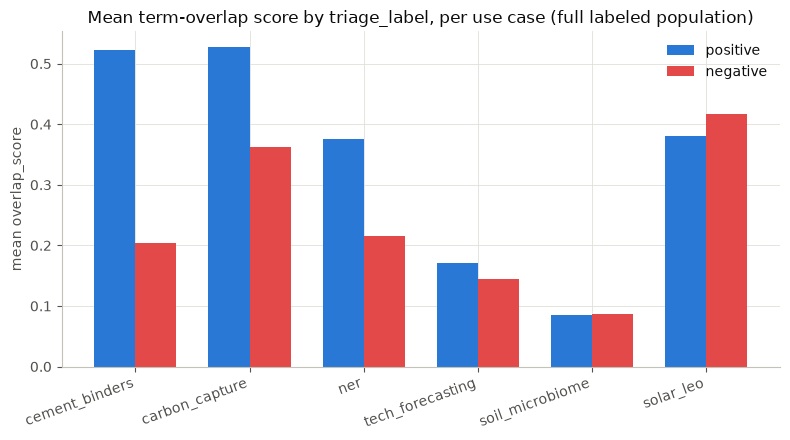

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.5))
order = full_summary.sort_values("auc", ascending=False)["use_case"]
plot_df = full_summary.set_index("use_case").loc[order]

x = np.arange(len(plot_df))
width = 0.36
ax.bar(x - width/2, plot_df["overlap_pos_mean"], width, label="positive", color=POSITIVE_COLOR)
ax.bar(x + width/2, plot_df["overlap_neg_mean"], width, label="negative", color=NEGATIVE_COLOR)
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=20, ha="right")
ax.set_ylabel("mean overlap_score")
ax.set_title("Mean term-overlap score by triage_label, per use case (full labeled population)")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## 6. Compare against `relevance_score` — correlated, or an independent signal?

Two checks: does `overlap_score` correlate with the existing `relevance_score` column
(if it's ~1.0, it's redundant), and how does `overlap_score` alone compare to
`relevance_score` alone at separating `positive`/`negative` (each used as a single-feature
ranking score — no fitting involved for either, so no cross-validation leakage risk to
guard against here, unlike a trained classifier).

In [10]:
corr_rows = []
for uc, g in labeled.groupby("use_case_key"):
    sub = g[["overlap_score", "relevance_score"]].dropna()
    r, p = stats.pearsonr(sub["overlap_score"], sub["relevance_score"])
    rho, ps = stats.spearmanr(sub["overlap_score"], sub["relevance_score"])
    y = (g["triage_label"] == "positive").astype(int)
    auc_overlap = roc_auc_score(y, g["overlap_score"])
    auc_relevance = roc_auc_score(y, g["relevance_score"])
    corr_rows.append({
        "use_case": uc, "n": len(sub),
        "pearson_r": round(r, 3), "pearson_p": round(p, 4),
        "spearman_rho": round(rho, 3),
        "overlap_AUC": round(auc_overlap, 3), "relevance_score_AUC": round(auc_relevance, 3),
    })
pd.DataFrame(corr_rows)

,use_case,n,pearson_r,pearson_p,spearman_rho,overlap_AUC,relevance_score_AUC
0,carbon_capture,297,0.271,0.0000,0.272,0.709,0.607
1,cement_binders,262,0.443,0.0000,0.425,0.801,0.903
2,ner,312,0.487,0.0000,0.524,0.698,0.717
3,soil_microbiome,357,0.104,0.0491,0.094,0.504,0.542
4,solar_leo,360,0.254,0.0000,0.089,0.464,0.594
5,tech_forecasting,264,0.314,0.0000,0.310,0.563,0.649


**Finding (hard numbers):** correlation with `relevance_score` is **moderate, not
redundant** — Pearson r ranges 0.10 (`soil_microbiome`) to 0.49 (`ner`), nowhere near
1.0. `overlap_score` and `relevance_score` are measuring related-but-different things.

Head-to-head at separating labels, `relevance_score` wins on `cement_binders` (0.903 vs.
0.801) and `tech_forecasting` (0.649 vs. 0.563), and edges it on `ner` (0.717 vs. 0.698).
**Surprising result:** on `carbon_capture`, the cheap term-overlap score actually
**beats** the existing agent-computed `relevance_score` (0.709 vs. 0.607). Both are weak
on `soil_microbiome`/`solar_leo` regardless of which is used. Read: not a replacement for
`relevance_score`, but not redundant with it either — a candidate additional feature,
strong on some use cases specifically because it captures something `relevance_score`
doesn't there.

## 7. Do `decision_must_have`/`decision_exclusions` add anything beyond `terms_*`?

Checked, not assumed. §1 already flagged that `decision_must_have` is long descriptive
prose (12–16.5 words/item) for 5 of 6 use cases, but for `tech_forecasting` it's short
keywords (1 word/item) — the one use case where folding it into the lexical match is
actually plausible.

In [11]:
cc = df[df.use_case_key == "carbon_capture"].iloc[0]
sentence = cc["decision_must_have"][0]
verbatim_hits = (df.loc[df.use_case_key == "carbon_capture", "text_norm"]
                  .map(lambda t: sentence.lower() in t).sum())
print(f"carbon_capture decision_must_have[0]: {sentence!r}")
print(f"verbatim matches of that full sentence across its {sum(df.use_case_key=='carbon_capture')} papers: {verbatim_hits}")

carbon_capture decision_must_have[0]: 'Uses a liquid amine solvent system (e.g. MEA or similar amine scrubbing solution)'
verbatim matches of that full sentence across its 323 papers: 0


In [12]:
tf = labeled[labeled.use_case_key == "tech_forecasting"].copy()
r0 = df[df.use_case_key == "tech_forecasting"].iloc[0]
combined_must = list(r0["terms_must_include"]) + list(r0["decision_must_have"])
combined_nice = list(r0["terms_nice_to_have"]) + list(r0["decision_nice_to_have"])

tf["must_fraction_plus_decision"] = [term_fraction(combined_must, tx) for tx in tf["text_norm"]]
tf["nice_fraction_plus_decision"] = [term_fraction(combined_nice, tx) for tx in tf["text_norm"]]
tf["overlap_score_plus_decision"] = (
    tf["must_fraction_plus_decision"].fillna(0) + 0.5 * tf["nice_fraction_plus_decision"].fillna(0)
    - tf["exclude_hit"].fillna(0)
)

y = (tf["triage_label"] == "positive").astype(int)
auc_terms_only = roc_auc_score(y, tf["overlap_score"])
auc_plus_decision = roc_auc_score(y, tf["overlap_score_plus_decision"])
print(f"tech_forecasting AUC, terms_* only:        {auc_terms_only:.3f}")
print(f"tech_forecasting AUC, terms_* + decision_*: {auc_plus_decision:.3f}")

tech_forecasting AUC, terms_* only:        0.563
tech_forecasting AUC, terms_* + decision_*: 0.553


**Finding (hard numbers):** `carbon_capture`'s `decision_must_have` sentence
never appears verbatim in any of its 323 papers (**0 matches**) — full-sentence
`decision_*` text is not usable as a literal-match term list for the 5 use cases where
it's prose; it restates the same requirements `terms_must_include` already encodes, just
in analyst-readable rule form. For `tech_forecasting`, the one use case where
`decision_must_have`/`decision_nice_to_have` are themselves short keywords, folding them
in was tested directly rather than assumed — it made separation marginally **worse**
(AUC 0.563 → 0.553), not better. **Verdict: `decision_*` adds nothing here** — `terms_*`
is already the right granularity, and the one case that looked promising didn't pan out
when tested.

## 8. Verdict

**Hard numbers:** term-overlap (whole-word match against `terms_must_include`/
`terms_nice_to_have`/`terms_exclude`) separates `positive` from `negative` papers with
full-population ROC-AUC 0.70–0.80 on 3 of 6 use cases (`cement_binders`, `carbon_capture`,
`ner`), all Mann-Whitney p < 0.0001, and correlates only moderately with `relevance_score`
(Pearson r 0.10–0.49) — a real, mostly-independent signal there, cheap to compute
(regex matching, no model, no embedding). On `carbon_capture` it even outperforms the
existing `relevance_score` at separating the labels (0.709 vs. 0.607).

On the other 3 use cases (`soil_microbiome`, `solar_leo`, `tech_forecasting`) it shows
**no reliable separation** (full-pop AUC 0.46–0.56, none significant at p < 0.05) —
`solar_leo` because its term lists are too sparse/near-tautological (§1, §5) to be
discriminative here, `soil_microbiome` despite having the richest term list of any use
case, and `tech_forecasting` marginally and inconsistently.

**Judgement call:** this is a promising, cheap, interpretable feature to add to a real
feature matrix — but only **conditionally per use case**, not as a blanket win. It's
worth adding as a feature for every use case regardless (cost is negligible and a
downstream model can learn to downweight it where it's uninformative), but anyone
reporting its value should say *which* use cases it helped on, not average the result
into one number that hides both the 0.80 AUCs and the near-chance ones.